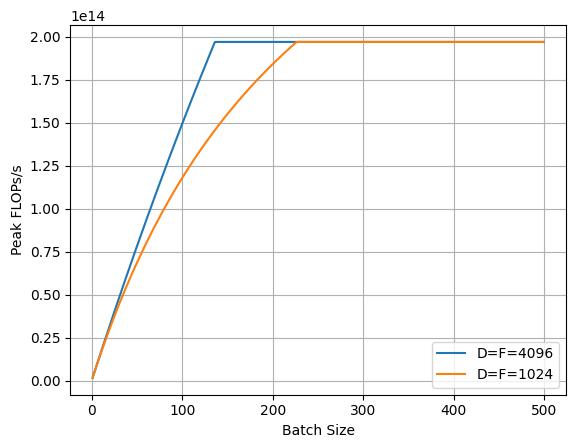

In [2]:
# Section 1 Q3
import matplotlib.pyplot as plt
import numpy as np

batch_size = np.arange(1, 500)

def peak_flops_per_second(B, D, F):
    total_flops = 2 * B * D * F
    t_math = total_flops / 1.97e14
    t_comms = (2 * B * D + D * F + 2 * B * F) / 8.2e11
    total_time = np.maximum(t_math, t_comms)
    return total_flops / total_time

roofline_4096 = peak_flops_per_second(batch_size, 4096, 4096)
roofline_1024 = peak_flops_per_second(batch_size, 1024, 1024)

plt.plot(batch_size, roofline_4096, label='D=F=4096')
plt.plot(batch_size, roofline_1024, label='D=F=1024')
plt.xlabel('Batch Size')
plt.ylabel('Peak FLOPs/s')
plt.legend()
plt.grid()

In [ ]:
# Section 3 Q8
import jax
jax.config.update("jax_num_cpu_devices", 8)

import jax.numpy as jnp
import jax.sharding as shd
from jax import jit

# Create our mesh! We're running on a fake 8 TPU mesh (4x2) with names 'X' and 'Y'.
assert len(jax.devices()) == 8
mesh = jax.make_mesh(axis_shapes=(4, 2), axis_names=('X', 'Y'))

# A little utility function to help define our sharding. A PartitionSpec is our
# sharding (a mapping from axes to names).
def P(*args):
  return shd.NamedSharding(mesh, shd.PartitionSpec(*args))

# We shard both A and B over the non-contracting dimension and A over the contracting dim.
A = jnp.zeros((8, 2048), dtype=jnp.bfloat16, device=P(None, 'Y'))
B = jnp.zeros((2048, 8192), dtype=jnp.bfloat16, device=P('Y', None))

# AllGather
@jit
def allgather(x):
  return jax.device_put(x, P(None, None))

# AllReduce
@jit
def allreduce(x):
  total = jnp.sum(x)
  return jax.device_put(total, P())

# ReduceScatter
@jit
def reducescatter(x, y):
  result = jnp.matmul(x, y)
  return jax.device_put(result, P('Y', None))

# AllToAll
@jit
def alltoall(x):
  return jax.device_put(x, P('Y', None))

print("AllGather")
%timeit allgather(A).block_until_ready()

print("AllReduce")
%timeit allreduce(A).block_until_ready()

print("ReduceScatter")
%timeit reducescatter(A, B).block_until_ready()

print("AllToAll")
%timeit alltoall(A).block_until_ready()

AllGather time: 
7.57 ms ± 287 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
AllReduce time: 
15.8 ms ± 2.53 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
ReduceScatter w/ MatMul time: 
383 ms ± 16.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
AllToAll time: 
8.04 ms ± 1.04 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
